### Proje için gerekli olan kütüphaneleri import etme

In [1]:
import pandas as pd # veri analizi için kullanılır. pd kısaltması ile Pandas kütüphanesine ait fonksiyonlara ulaşırız.
import numpy as np # veri manipülasyonunda ve Matematiksel işlemlerde kullanılan Python kütüphanesi
import plotly.express as px # İnteraktif grafikler oluşturmaya yarayan veri görselleştirmede kullanacağımız kütüphane

### Veri Setini CSV formatından DataFrame Formatına dönüştürme

In [2]:
df = pd.read_csv("rfm_data.csv")

### EDA (Exploratory Data Analysis) Veri setini keşfetme.

In [3]:
print(f"Veri setimizin satır sayısı: {df.shape[0]}") # veri setinin gözlem (satır) sayısını bulma
print(f"Veri setimizin sütun sayısı: {df.shape[1]}") # veri setinin sütun sayısını bulma

Veri setimizin satır sayısı: 1000
Veri setimizin sütun sayısı: 4


In [4]:
print(f"Boş hücre kontrolü: {df.isna().sum()}") # veri setindeki hücrelere göre boş hücre sayısını görelim. Boş hücreler varsa bu hücreleri dolduracağız.

Boş hücre kontrolü: order_id        0
customer_id     0
order_date      0
revenue        32
dtype: int64


In [5]:
print(df.info())# veri seti hakkında genel bilgiler (kapladığı alan, sütunların (veri tipi), veri setinin class'ı ..)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   order_id     1000 non-null   int64  
 1   customer_id  1000 non-null   object 
 2   order_date   1000 non-null   object 
 3   revenue      968 non-null    float64
dtypes: float64(1), int64(1), object(2)
memory usage: 31.4+ KB
None


In [6]:
print(df.describe()) # veri setindeki sayısal (int, float) sütunlar üzerinde descriptive (tanımlayıcı) istatistik bilgilerini görüntülüyoruz.

          order_id      revenue
count  1000.000000   968.000000
mean    500.500000   354.648760
std     288.819436   443.823615
min       1.000000  -100.000000
25%     250.750000   100.000000
50%     500.500000   250.000000
75%     750.250000   500.000000
max    1000.000000  2000.000000


### Keşifsel veri analizi (EDA) sonuçları
* Veri setimiz 1000 satır ve 4 sütundan oluşmaktadır. Bu sütunları sırasıyla order_id, customer_id, order_date ve revenue.

**Veri seti sütunlarını tanıtma**
* order_id: Int türünde bir sütun ve siparişlerin id numaralarını tutar.
* customer_id: Object türünde bir sütun ve müşterilerin id numaralarını tutar.
* order_date: Object türünde bir sütun ve siparişlerin tarih bilgisini tutar.
* revenue: Float türünde bir sütundur ve siparişlerden elde edilen geliri gösterir.
  
**Veri seti hakkında diğer hususlar**
* Veri setimizin revenue sütununda 32 adet boş hücre var. İlerleyen aşamalarda bu kısımları nasıl dolduracağımıza karar vereceğiz.
* Veri setimizde revenue sütununda minimum değer -100 gelir -100 olamayacağı için bu sütunlar hatalı veridir. Bu satırları veri temizleme aşamasında sileceğiz.

### Veri temizleme ve Feature Engineering

In [7]:
## Veri setindeki negatif revenue değerleri bu sütundaki medyan/ortalama değerlerini bozabileceği için önce bu satırları veri setinden siliyoruz.
cleaned_df = df[df["revenue"]>0].copy() # temizlenen veri setini cleaned_df değişkenine atadık.

In [8]:
print(f"Temizlenen veri setinin gözlem (satır) sayısı: {cleaned_df.shape[0]}") ## Temizlenen veri setinin satır sayısını kontrol ediyoruz.

Temizlenen veri setinin gözlem (satır) sayısı: 948


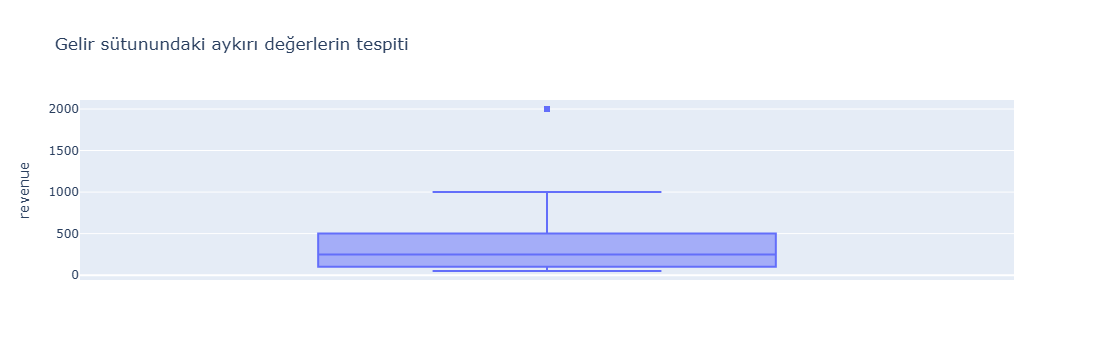

In [9]:
# revenue sütunundaki negatif değerleri kaldırdıktan sonra bu sütundaki boş verilerin ortalama mı yoksa medyanla mı doldurulacağına karar vermek için boxplot çizelim.
fig=px.box( # box plot grafiğini kullanarak outlier (uçdeğer) tespiti yapıyoruz.
    cleaned_df,
    y = "revenue",
    points="outliers", # outlier noktaları gösterir.
    title = "Gelir sütunundaki aykırı değerlerin tespiti"
) 
fig.show()

#### Boxplot yorumu
* Veri setinin revenue sütununda aykırı değer bulunduğu için bu sütundaki boş hücrelerin ilgili sütunun medyan değeriyle doldurulmasına karar verilmiştir.
* Neden medyan ? : Medyan uç değerlere dayanıklı olduğundan dolayı veri setindeki boş hücrelerin daha sağlıklı doldurulmasını sağlar. Eğer veri setimizde uç değer olmasaydı bu sütunları ortalama ile doldururduk ancak ortalama uç değerlere duyarlı olduğu için boş hücrelerin gerçekçi değerlerle doldurulmasının önüne geçer.

In [10]:
revenue_median = cleaned_df["revenue"].median() # veri setindeki boş hücreleri ilgili sütunun medyan değeriyle dolduruyoruz.
cleaned_df["revenue"] = cleaned_df["revenue"].fillna(value = revenue_median)

In [11]:
print(cleaned_df["revenue"].isna().sum())# Boş değer kalıp kalmadığını kontrol edelim

0


In [12]:
cleaned_df["order_date"] = pd.to_datetime(cleaned_df["order_date"], format="%Y-%m-%d") # order date sütununu DateTime türüne dönüştürüyoruz. "%Y" 4 haneli yıl, %m 01-12 Arası ayları temsil eder. %d ise günleri temsil eder.
print(cleaned_df["order_date"].dtype) # order_date sütunun veri tipini kontrol edelim.

datetime64[ns]


### RFM nedir?
* Recency(Yenilik): Müşterinin en son ne zaman alışveriş yaptığını gösterir. Genellikle "Analiz Tarihi - Son Satın Alma Tarihi" formülüyle gün cinsinden hesaplanır. Skorun düşük olması, müşterinin daha güncel (canlı) olduğunu gösterir.
* Frequency(Sıklık): Müşterinin toplamda kaç kez alışveriş yaptığını ifade eder. İşlem sayısının yüksek olması, müşterinin markayı sık tercih ettiğini gösterir
* Monetary(Parasal Değer): Müşterinin yaptığı harcamaların toplam parasal tutarıdır.Şirkete bıraktığı toplam ciroyu gösterir. Skorun yüksek olması, müşterinin maddi getirisinin fazla olduğunu gösterir.

In [13]:
most_recent_order_date = cleaned_df["order_date"].max() # Öncelikle recency hesaplamak için en yeni sipariş tarihini bulalım
print(f"En güncel sipariş tarihi: {most_recent_order_date}")

En güncel sipariş tarihi: 2024-12-31 00:00:00


In [14]:
# Şimdi bu bulduğumuz tarih üzerinden her bir müşteri için recency hesaplayacağız. Bunu yeni bir DataFrame ile yapalım.
rfm = cleaned_df.groupby("customer_id").agg(most_recent_order_date =("order_date", "max")) # Bütün müşterileri gruplayıp her biri için en güncel sipariş tarihini buluyoruz.
recency = (most_recent_order_date - cleaned_df.groupby("customer_id")["order_date"].max()).dt.days
rfm["recency"] = recency

In [15]:
rfm.head()

,most_recent_order_date,recency
customer_id,,
C0001,2024-07-15,169
C0002,2024-12-22,9
C0003,2024-11-19,42
C0004,2024-10-03,89
C0005,2024-07-07,177


In [16]:
# her müşteri için frequency değerlerini hesaplayalım.
frequency = cleaned_df.groupby("customer_id").agg(frequency = ("order_id", "count")) # müşterileri grupla her bir müşterinin order (siparişlerini say) ve bunu frequency'e ata.
rfm["frequency"] = frequency # rfm dataframe'ine frequency sütununu ekle.
rfm.head()

,most_recent_order_date,recency,frequency
customer_id,,,
C0001,2024-07-15,169,8
C0002,2024-12-22,9,5
C0003,2024-11-19,42,6
C0004,2024-10-03,89,3
C0005,2024-07-07,177,6


In [17]:
monetary = cleaned_df.groupby("customer_id").agg(monetary = ("revenue", "sum"))# her bir müşterinin şirkete getirdiği toplam geliri hesaplayalım.
print(monetary.head())

             monetary
customer_id          
C0001          3050.0
C0002           800.0
C0003          3350.0
C0004           850.0
C0005          2750.0


In [18]:
rfm["monetary"] = monetary # rfm tablosuna monetary, frequency ve recency bilgilerini eklemiş oluyoruz.

In [19]:
# tablo kontrol 
rfm.head()

,most_recent_order_date,recency,frequency,monetary
customer_id,,,,
C0001,2024-07-15,169,8,3050.0
C0002,2024-12-22,9,5,800.0
C0003,2024-11-19,42,6,3350.0
C0004,2024-10-03,89,3,850.0
C0005,2024-07-07,177,6,2750.0


In [20]:
# Müşterilerimize recency, frequency ve monetary  durumlarına göre 1-5 arası puanlar vereceğiz. 
rfm["r_score"] = pd.qcut(rfm["recency"], q=5, labels=[5,4,3,2,1]) # qcut fonksiyonu veriyi küçükten büyüğe sıralar. Bu sıralamada tarihsel olarak en yeni(küçük) olan değere
# 5 verebilmek için labels değerlerini 5-4-3-2-1 olarak değiştirdik.
rfm["f_score"] = pd.qcut(rfm["frequency"].rank(method="first"), q=5, labels=[1,2,3,4,5])
rfm["m_score"] = pd.qcut(rfm["monetary"], q=5, labels=[1,2,3,4,5])
rfm.head()

,most_recent_order_date,recency,frequency,monetary,r_score,f_score,m_score
customer_id,,,,,,,
C0001,2024-07-15,169,8,3050.0,2,5,5
C0002,2024-12-22,9,5,800.0,5,3,2
C0003,2024-11-19,42,6,3350.0,4,4,5
C0004,2024-10-03,89,3,850.0,3,1,2
C0005,2024-07-07,177,6,2750.0,2,4,4


In [21]:
# müşterin recency monetary ve frequency bilgilerini RFM score olarak birleştiriyoruz. Bu birleştirmeyi segmentasyonda kullanacağız.
rfm["RFM_score"] = rfm["r_score"].astype(str) + rfm["f_score"].astype(str) + rfm["m_score"].astype(str)
rfm.head() 

,most_recent_order_date,recency,frequency,monetary,r_score,f_score,m_score,RFM_score
customer_id,,,,,,,,
C0001,2024-07-15,169,8,3050.0,2,5,5,255
C0002,2024-12-22,9,5,800.0,5,3,2,532
C0003,2024-11-19,42,6,3350.0,4,4,5,445
C0004,2024-10-03,89,3,850.0,3,1,2,312
C0005,2024-07-07,177,6,2750.0,2,4,4,244


In [22]:
# Müşterileri r,f,m değerlerine göre gruplamak için özel bir fonksiyon tanımlıyoruz.
def rfm_segment(row):
    r = int(row["r_score"])
    f = int(row["f_score"])
    m = int(row["m_score"])
    
    if r >= 4 and f >= 4 and m >= 4:
        return "Şampiyon"
    elif r >= 3 and f >= 3 and m >= 3:
        return "Sadık Müşteri"
    elif r >= 4 and f <= 2:
        return "Yeni Müşteri"
    elif r <= 2 and f >= 3 and m >= 3:
        return "Kaybedilmek Üzere"
    elif r <= 2 and f <= 2 and m <= 2:
        return "Kayıp Müşteri"
    else:
        return "Orta Segment"

rfm["segment"] = rfm.apply(rfm_segment, axis=1) # Yukarıda tanımlamış olduğumuz fonksiyonu bütün satırlara uyguluyoruz (apply).

In [23]:
segments = rfm["segment"].value_counts() # her bir segment için o segmente ait kişi sayısını hesaplayalım.
segments_df= pd.DataFrame(segments) # segments serisini dataframe formatına dönüştürelim.

In [24]:
segments_df = segments_df.rename(columns = {"count":"insan sayısı"}) # yeni dataframe'deki sütuna anlamlı bir isim verelim.
segments_df.head()

,insan sayısı
segment,
Orta Segment,50
Sadık Müşteri,37
Kaybedilmek Üzere,30
Kayıp Müşteri,29
Şampiyon,26


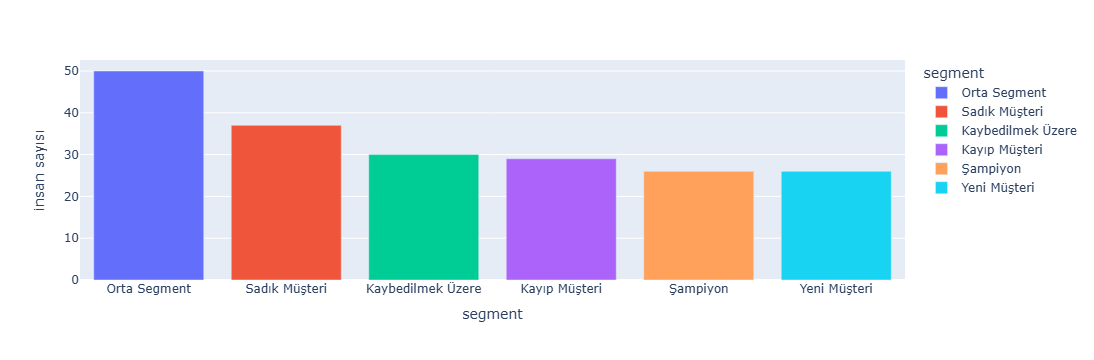

In [25]:
fig = px.bar( # dataframe'deki segmentlere ait insan sayılarını görselleştirerek aradaki farkı görelim.
    segments_df,
    x = segments_df.index,
    y = "insan sayısı",
    color = segments_df.index
)
fig.show()

### Sonuç
* En fazla orta segment müşterimiz bulunurken en az yeni müşterilerimiz ve şampiyon müşterilerimiz bulunmaktadır. 
* Kaybedilmek üzere, kayıp müşteri, şampiyon ve yeni müşteri sayıları oldukça yakın. Bu durumda kaybedilmek üzere olan ve yeni müşterilere yönelik yeni kampanyalar düzenleyebiliriz.
* Örneğin orta segment müşterilere ve kaybedilmek üzere olan müşterilere yönelik yapılacak indirimlerle veya onlara özel gönderilecek bildirimlerle/maillerle onları daha da çok alışverişe yönlendirebiliriz.
* Yeni müşterilerimizin sayısını artırmak için ise onlara özel ücretsiz kargo hizmeti sunulabilir. Aynı şekilde yapacağımız indirimlerden yeni müşterilerimizin de faydalanmasını sağlayabiliriz.